In [1]:
import xarray as xr
import os

era5_dir = "../datos/ERA5"
archivos = sorted(os.listdir(era5_dir))
print(archivos)

['.DS_Store', 'era5_10m_u_component_of_wind_1980_2023.nc', 'era5_10m_v_component_of_wind_1980_2023.nc', 'era5_2m_dewpoint_temperature_1980_2023.nc', 'era5_2m_temperature_1980_2023.nc', 'era5_msdwlwrf_1980_2023.nc', 'era5_msdwswrf_1980_2023.nc', 'era5_surface_solar_radiation_downwards_1980.nc', 'era5_surface_solar_radiation_downwards_1980_2023.nc', 'era5_surface_solar_radiation_downwards_1981.nc', 'era5_surface_solar_radiation_downwards_1982.nc', 'era5_surface_solar_radiation_downwards_1983.nc', 'era5_surface_solar_radiation_downwards_1984.nc', 'era5_surface_solar_radiation_downwards_1985.nc', 'era5_surface_solar_radiation_downwards_1986.nc', 'era5_surface_solar_radiation_downwards_1987.nc', 'era5_surface_solar_radiation_downwards_1988.nc', 'era5_surface_solar_radiation_downwards_1989.nc', 'era5_surface_solar_radiation_downwards_1990.nc', 'era5_surface_solar_radiation_downwards_1991.nc', 'era5_surface_solar_radiation_downwards_1992.nc', 'era5_surface_solar_radiation_downwards_1993.nc', 

In [4]:
import xarray as xr
import numpy as np
import os

era5_dir = "../datos/ERA5"

# Variables atmosfericas
t2m  = xr.open_dataset(f"{era5_dir}/era5_2m_temperature_1980_2023.nc")["t2m"]
td2m = xr.open_dataset(f"{era5_dir}/era5_2m_dewpoint_temperature_1980_2023.nc")["d2m"]
u10  = xr.open_dataset(f"{era5_dir}/era5_10m_u_component_of_wind_1980_2023.nc")["u10"]
v10  = xr.open_dataset(f"{era5_dir}/era5_10m_v_component_of_wind_1980_2023.nc")["v10"]

# SW y LW en W/m2 directamente
sw_flux = xr.open_dataset(f"{era5_dir}/era5_msdwswrf_1980_2023.nc")["avg_sdswrf"]
lw_flux = xr.open_dataset(f"{era5_dir}/era5_msdwlwrf_1980_2023.nc")["avg_sdlwrf"]

sw_flux = sw_flux.assign_coords(valid_time=sw_flux.valid_time.astype("datetime64[D]")).rename({"valid_time": "time"})
lw_flux = lw_flux.assign_coords(valid_time=lw_flux.valid_time.astype("datetime64[D]")).rename({"valid_time": "time"})

sw_flux.name = "sw"
lw_flux.name = "lw"

print("t2m:", t2m.shape)
print("SW min/max:", float(sw_flux.min()), float(sw_flux.max()))
print("LW min/max:", float(lw_flux.min()), float(lw_flux.max()))
print("SW time[0:3]:", sw_flux.time.values[:3])

t2m: (16071, 33, 29)
SW min/max: 0.0 146.0
LW min/max: 189.33706665039062 456.449951171875
SW time[0:3]: ['1980-01-01T00:00:00' '1980-01-02T00:00:00' '1980-01-03T00:00:00']


In [5]:
# Calcular humedad específica y velocidad del viento
e  = 6.112 * np.exp(17.67 * (td2m - 273.15) / (td2m - 273.15 + 243.5))
es = 6.112 * np.exp(17.67 * (t2m  - 273.15) / (t2m  - 273.15 + 243.5))

p = 1013.25
q = 0.622 * e / (p - 0.378 * e)
q.name = "q"
q.attrs["units"] = "kg/kg"
q.attrs["long_name"] = "specific humidity"

wspd = np.sqrt(u10**2 + v10**2)
wspd.name = "wspd"
wspd.attrs["units"] = "m/s"
wspd.attrs["long_name"] = "wind speed"

t2m_c = t2m - 273.15
t2m_c.name = "t2m"
t2m_c.attrs["units"] = "degC"
t2m_c.attrs["long_name"] = "2m air temperature"

# Normalizar timestamps a fecha sin hora para alinear con sw_daily y lw_daily
t2m_c = t2m_c.assign_coords(valid_time=t2m_c.valid_time.astype("datetime64[D]")).rename({"valid_time": "time"})
q     = q.assign_coords(valid_time=q.valid_time.astype("datetime64[D]")).rename({"valid_time": "time"})
wspd  = wspd.assign_coords(valid_time=wspd.valid_time.astype("datetime64[D]")).rename({"valid_time": "time"})

print("q    min/max:", float(q.min()), float(q.max()))
print("wspd min/max:", float(wspd.min()), float(wspd.max()))
print("t2m  min/max:", float(t2m_c.min()), float(t2m_c.max()))
print("t2m  time[0:3]:", t2m_c.time.values[:3])

q    min/max: 0.001189401838928461 0.02348513901233673
wspd min/max: 7.62939453125e-05 15.263882637023926
t2m  min/max: 0.357086181640625 32.425445556640625
t2m  time[0:3]: ['1980-01-01T00:00:00' '1980-01-02T00:00:00' '1980-01-03T00:00:00']


In [6]:
ds_era5 = xr.Dataset({
    "t2m":  t2m_c,
    "q":    q,
    "wspd": wspd,
    "sw":   sw_flux,
    "lw":   lw_flux,
})

ds_era5 = ds_era5.drop_vars(["expver", "number"], errors="ignore")
print(ds_era5)
print("NaN en t2m:", int(ds_era5["t2m"].isnull().sum()))
print("NaN en sw:", int(ds_era5["sw"].isnull().sum()))

<xarray.Dataset> Size: 308MB
Dimensions:    (latitude: 33, longitude: 29, time: 16071)
Coordinates:
  * latitude   (latitude) float64 264B 8.0 7.75 7.5 7.25 ... 0.75 0.5 0.25 0.0
  * longitude  (longitude) float64 232B -82.0 -81.75 -81.5 ... -75.25 -75.0
  * time       (time) datetime64[s] 129kB 1980-01-01 1980-01-02 ... 2023-12-31
Data variables:
    t2m        (time, latitude, longitude) float32 62MB 26.23 25.86 ... 24.79
    q          (time, latitude, longitude) float32 62MB 0.01769 ... 0.01882
    wspd       (time, latitude, longitude) float32 62MB 2.19 1.114 ... 0.8861
    sw         (time, latitude, longitude) float32 62MB 2.594 3.0 ... 54.5 54.62
    lw         (time, latitude, longitude) float32 62MB 413.1 407.5 ... 406.4
NaN en t2m: 0
NaN en sw: 0


In [10]:
output_path = "../datos/procesados/era5_procesado.nc"
ds_era5.to_netcdf(output_path)
print(f"Guardado en {output_path}")
print(f"Tamaño: {os.path.getsize(output_path) / 1e6:.1f} MB")

Guardado en ../datos/procesados/era5_procesado.nc
Tamaño: 234.3 MB


In [8]:
import glob

oisst_dir = "../datos/OISST"

# Abrir todos los archivos anuales
files = sorted(glob.glob(f"{oisst_dir}/oisst_????.nc"))
print(f"Archivos encontrados: {len(files)}")

ds_oisst = xr.open_mfdataset(files, combine="by_coords")
print(ds_oisst)

Archivos encontrados: 42
<xarray.Dataset> Size: 59MB
Dimensions:  (time: 15331, zlev: 1, lat: 33, lon: 29)
Coordinates:
  * time     (time) datetime64[ns] 123kB 1982-01-01T12:00:00 ... 2023-12-31T1...
  * zlev     (zlev) float32 4B 0.0
  * lat      (lat) float32 132B 0.125 0.375 0.625 0.875 ... 7.625 7.875 8.125
  * lon      (lon) float32 116B 277.9 278.1 278.4 278.6 ... 284.4 284.6 284.9
Data variables:
    sst      (time, zlev, lat, lon) float32 59MB dask.array<chunksize=(365, 1, 33, 29), meta=np.ndarray>


In [10]:
# Eliminar dimension zlev, normalizar timestamps y coordenadas
sst = ds_oisst["sst"].squeeze("zlev")
sst = sst.assign_coords(time=sst.time.astype("datetime64[D]"))
sst = sst.rename({"lat": "latitude", "lon": "longitude"})

# Convertir longitudes de 0-360 a -180-180
sst = sst.assign_coords(longitude=(sst.longitude - 360))

# Rechunkear para que time sea un solo chunk antes de interpolar
sst = sst.chunk({"time": -1})

# Interpolar dias faltantes
sst = sst.interpolate_na(dim="time", method="linear")

print(sst)
print("NaN restantes:", int(sst.isnull().sum()))
print("tiempo[0:3]:", sst.time.values[:3])

<xarray.DataArray 'sst' (time: 15331, latitude: 33, longitude: 29)> Size: 59MB
dask.array<transpose, shape=(15331, 33, 29), dtype=float32, chunksize=(15331, 33, 29), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[s] 123kB 1982-01-01 1982-01-02 ... 2023-12-31
  * latitude   (latitude) float32 132B 0.125 0.375 0.625 ... 7.625 7.875 8.125
  * longitude  (longitude) float32 116B -82.12 -81.88 -81.62 ... -75.38 -75.12
    zlev       float32 4B 0.0
Attributes:
    long_name:    Daily sea surface temperature
    units:        Celsius
    valid_min:    -300
    valid_max:    4500
    _ChunkSizes:  [   1    1  720 1440]
NaN restantes: 6377696
tiempo[0:3]: ['1982-01-01T00:00:00' '1982-01-02T00:00:00' '1982-01-03T00:00:00']


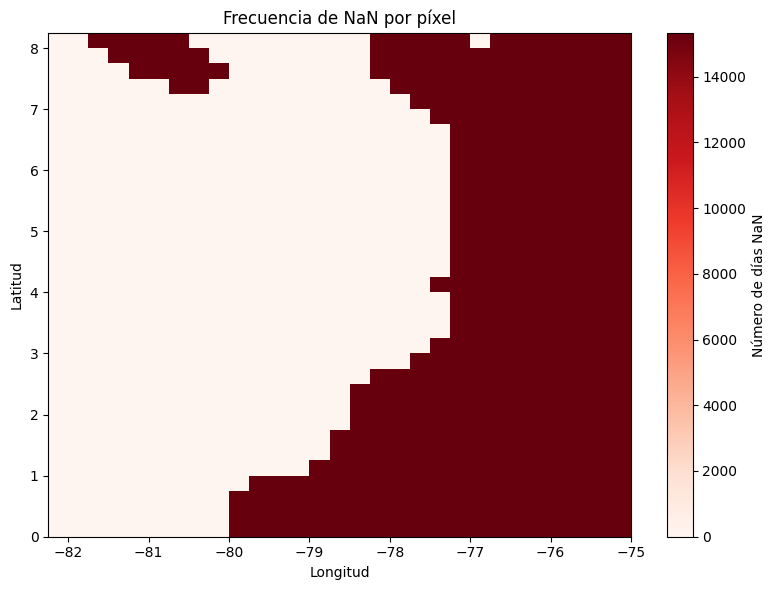

Píxeles siempre NaN (tierra): 416
Píxeles con NaN parcial (huecos reales): 0
Total píxeles: 957


In [11]:
import matplotlib.pyplot as plt

# Mapa de frecuencia de NaN por pixel (cuantos dias es NaN cada pixel)
nan_count = sst.isnull().sum(dim="time").compute()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(sst.longitude, sst.latitude, nan_count, cmap="Reds")
plt.colorbar(im, ax=ax, label="Número de días NaN")
ax.set_title("Frecuencia de NaN por píxel")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
plt.tight_layout()
plt.show()

# Cuantos pixeles tienen NaN en TODOS los dias (tierra permanente)
total_dias = sst.sizes["time"]
tierra = int((nan_count == total_dias).sum())
parcial = int(((nan_count > 0) & (nan_count < total_dias)).sum())
print(f"Píxeles siempre NaN (tierra): {tierra}")
print(f"Píxeles con NaN parcial (huecos reales): {parcial}")
print(f"Total píxeles: {sst.sizes['latitude'] * sst.sizes['longitude']}")

In [12]:
# Verificar que no hay fechas faltantes en la serie temporal
fechas = sst.time.values
fechas_esperadas = np.arange(
    np.datetime64("1982-01-01"),
    np.datetime64("2024-01-01"),
    np.timedelta64(1, "D")
)
faltantes = np.setdiff1d(fechas_esperadas, fechas)
print("Fechas faltantes en el índice temporal:", len(faltantes))
if len(faltantes) > 0:
    print(faltantes)

Fechas faltantes en el índice temporal: 9
['1989-03-01' '1994-04-15' '2017-02-05' '2017-02-11' '2017-02-13'
 '2017-02-15' '2017-02-23' '2017-02-26' '2020-06-16']


In [13]:
# Eliminar dimension zlev, normalizar timestamps y coordenadas
sst = ds_oisst["sst"].squeeze("zlev")
sst = sst.assign_coords(time=sst.time.astype("datetime64[D]"))
sst = sst.rename({"lat": "latitude", "lon": "longitude"})
sst = sst.assign_coords(longitude=(sst.longitude - 360))

# Reindexar para insertar fechas faltantes como NaN
fechas_completas = np.arange(
    np.datetime64("1982-01-01"),
    np.datetime64("2024-01-01"),
    np.timedelta64(1, "D")
)
sst = sst.reindex(time=fechas_completas)

# Rechunkear e interpolar
sst = sst.chunk({"time": -1})
sst = sst.interpolate_na(dim="time", method="linear")

# Verificar
fechas = sst.time.values
faltantes = np.setdiff1d(fechas_completas, fechas)
print("Fechas faltantes tras reindex:", len(faltantes))
print("NaN por pixel (tierra vs huecos):")
nan_count = sst.isnull().sum(dim="time").compute()
total_dias = sst.sizes["time"]
print(f"  Píxeles siempre NaN (tierra): {int((nan_count == total_dias).sum())}")
print(f"  Píxeles con NaN parcial:      {int(((nan_count > 0) & (nan_count < total_dias)).sum())}")
print(f"  Total días en serie:          {total_dias}")

Fechas faltantes tras reindex: 0
NaN por pixel (tierra vs huecos):
  Píxeles siempre NaN (tierra): 416
  Píxeles con NaN parcial:      0
  Total días en serie:          15340


In [14]:
ds_oisst_proc = sst.to_dataset(name="sst")
ds_oisst_proc = ds_oisst_proc.drop_vars(["zlev"], errors="ignore")

output_path = "../datos/procesados/oisst_procesado.nc"
ds_oisst_proc.to_netcdf(output_path)
print(f"Guardado en {output_path}")
print(f"Tamaño: {os.path.getsize(output_path) / 1e6:.1f} MB")

Guardado en ../datos/procesados/oisst_procesado.nc
Tamaño: 58.9 MB


In [15]:
ds_mld = xr.open_dataset("../datos/MLD/mld_climatologia_mensual.nc")
print(ds_mld)

<xarray.Dataset> Size: 94MB
Dimensions:        (iLAT: 180, iLON: 360, iMONTH: 12)
Dimensions without coordinates: iLAT, iLON, iMONTH
Data variables: (12/20)
    lat            (iLAT) float64 1kB ...
    lon            (iLON) float64 3kB ...
    month          (iMONTH) float64 96B ...
    mld_da_mean    (iLAT, iLON, iMONTH) float64 6MB ...
    mld_dt_mean    (iLAT, iLON, iMONTH) float64 6MB ...
    mld_da_median  (iLAT, iLON, iMONTH) float64 6MB ...
    ...             ...
    mlt_dt         (iLAT, iLON, iMONTH) float64 6MB ...
    mls_da         (iLAT, iLON, iMONTH) float64 6MB ...
    mls_dt         (iLAT, iLON, iMONTH) float64 6MB ...
    num            (iLAT, iLON, iMONTH) float64 6MB ...
    longrid        (iLAT, iLON) float64 518kB ...
    latgrid        (iLAT, iLON) float64 518kB ...
Attributes:
    description:  This file was created using \n matlab R2011b with NETCDF Li...
    date:         [730848.53015047 730848.88790506 730849.28543982 ... 738591...


In [17]:
ds_mld = xr.open_dataset("../datos/MLD/mld_climatologia_mensual.nc")

ds_mld = ds_mld.assign_coords({
    "iLAT": ds_mld["lat"].values,
    "iLON": ds_mld["lon"].values,
    "iMONTH": ds_mld["month"].values.astype(int),
}).rename({"iLAT": "latitude", "iLON": "longitude", "iMONTH": "mes"})

mld = ds_mld["mld_dt_mean"]

print(mld)
print("lat range:", float(mld.latitude.min()), float(mld.latitude.max()))
print("lon range:", float(mld.longitude.min()), float(mld.longitude.max()))

<xarray.DataArray 'mld_dt_mean' (latitude: 180, longitude: 360, mes: 12)> Size: 6MB
[777600 values with dtype=float64]
Coordinates:
  * latitude   (latitude) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * longitude  (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
  * mes        (mes) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    long_name:        Monthly mean of the MLDs found by the density threshold...
    standard_name:    mld_dt_mean
    units:            meters
    _CoordinateAxis:  month lat lon
    valid_min:        95.0
    valid_max:        116.0
    title:            Monthly mean of the MLDs found by the density threshold...
    institution:      SIO
lat range: -89.5 89.5
lon range: -179.5 179.5


In [18]:
from scipy.interpolate import RegularGridInterpolator
import numpy as np

# Recortar region de interes
mld_region = mld.sel(latitude=slice(0, 8), longitude=slice(-82, -75))
print("MLD region:")
print(mld_region)
print("valores mes 1:\n", mld_region.isel(mes=0).values)

MLD region:
<xarray.DataArray 'mld_dt_mean' (latitude: 8, longitude: 7, mes: 12)> Size: 5kB
[672 values with dtype=float64]
Coordinates:
  * latitude   (latitude) float64 64B 0.5 1.5 2.5 3.5 4.5 5.5 6.5 7.5
  * longitude  (longitude) float64 56B -81.5 -80.5 -79.5 -78.5 -77.5 -76.5 -75.5
  * mes        (mes) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    long_name:        Monthly mean of the MLDs found by the density threshold...
    standard_name:    mld_dt_mean
    units:            meters
    _CoordinateAxis:  month lat lon
    valid_min:        95.0
    valid_max:        116.0
    title:            Monthly mean of the MLDs found by the density threshold...
    institution:      SIO
valores mes 1:
 [[        nan         nan         nan         nan         nan         nan
          nan]
 [17.15441129         nan         nan         nan         nan         nan
          nan]
 [ 9.90493608 11.28722301 13.77329996 31.42371995         nan         nan
          nan]
 [        nan    

In [19]:
from scipy.interpolate import RegularGridInterpolator
import numpy as np

# Target: grid ERA5 (0.25 grados)
lat_era5 = np.arange(0.0, 8.25, 0.25)
lon_era5 = np.arange(-82.0, -74.75, 0.25)

mld_interp = np.full((12, len(lat_era5), len(lon_era5)), np.nan)

for m in range(12):
    datos = mld_region.isel(mes=m).values  # shape (8, 7)
    lats = mld_region.latitude.values
    lons = mld_region.longitude.values

    # Rellenar NaN con media de vecinos validos para poder interpolar
    from scipy.ndimage import generic_filter
    def nanmean_filter(x):
        v = x[~np.isnan(x)]
        return np.nanmean(v) if len(v) > 0 else np.nan
    
    datos_filled = generic_filter(datos, nanmean_filter, size=3, mode="nearest")

    # Interpolar al grid ERA5
    interp = RegularGridInterpolator(
        (lats, lons), datos_filled,
        method="linear", bounds_error=False, fill_value=None
    )
    pts = np.array([[la, lo] for la in lat_era5 for lo in lon_era5])
    mld_interp[m] = interp(pts).reshape(len(lat_era5), len(lon_era5))

print("MLD interpolado shape:", mld_interp.shape)
print("min/max:", np.nanmin(mld_interp), np.nanmax(mld_interp))
print("NaN restantes:", np.isnan(mld_interp).sum())

MLD interpolado shape: (12, 33, 29)
min/max: 8.469777366198116 44.20485571959143
NaN restantes: 4632


In [20]:
from scipy.ndimage import distance_transform_edt

mld_interp_filled = mld_interp.copy()

for m in range(12):
    capa = mld_interp[m]
    mascara_nan = np.isnan(capa)
    if mascara_nan.any():
        # Nearest neighbor fill: copiar valor del pixel valido mas cercano
        indices = distance_transform_edt(mascara_nan, return_distances=False, return_indices=True)
        mld_interp_filled[m] = capa[tuple(indices)]

print("NaN restantes tras fill:", np.isnan(mld_interp_filled).sum())
print("min/max:", np.nanmin(mld_interp_filled), np.nanmax(mld_interp_filled))

NaN restantes tras fill: 0
min/max: 8.469777366198116 44.20485571959143


In [21]:
ds_mld_proc = xr.DataArray(
    mld_interp_filled,
    dims=["month", "latitude", "longitude"],
    coords={
        "month": np.arange(1, 13),
        "latitude": lat_era5,
        "longitude": lon_era5,
    },
    name="mld",
    attrs={"units": "m", "long_name": "mixed layer depth monthly climatology"}
).to_dataset()

output_path = "../datos/procesados/mld_procesado.nc"
ds_mld_proc.to_netcdf(output_path)
print(f"Guardado en {output_path}")
print(f"Tamaño: {os.path.getsize(output_path) / 1e6:.1f} MB")

Guardado en ../datos/procesados/mld_procesado.nc
Tamaño: 0.1 MB


In [22]:
ds_chirps = xr.open_dataset("../datos/CHIRPS/chirps-v2.0.monthly.nc")
print(ds_chirps)

<xarray.Dataset> Size: 31GB
Dimensions:    (time: 544, latitude: 2000, longitude: 7200)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1981-01-01 1981-02-01 ... 2026-04-01
  * latitude   (latitude) float32 8kB -49.97 -49.92 -49.88 ... 49.87 49.92 49.97
  * longitude  (longitude) float32 29kB -180.0 -179.9 -179.9 ... 179.9 180.0
Data variables:
    precip     (time, latitude, longitude) float32 31GB ...
Attributes: (12/15)
    Conventions:       CF-1.6
    title:             CHIRPS Version 2.0
    history:           created by Climate Hazards Group
    version:           Version 2.0
    date_created:      2026-05-15
    creator_name:      Pete Peterson
    ...                ...
    reference:         Funk, C.C., Peterson, P.J., Landsfeld, M.F., Pedreros,...
    comments:           time variable denotes the first day of the given month.
    acknowledgements:  The Climate Hazards Group InfraRed Precipitation with ...
    ftp_url:           ftp://chg-ftpout.geog.ucsb.edu/pub/org/ch

In [23]:
# Recortar region costera y andina adyacente (2-8N, 73-78W)
# sin cargar el archivo completo
chirps = ds_chirps["precip"].sel(
    latitude=slice(2, 8),
    longitude=slice(-78, -73),
    time=slice("1981-01-01", "2023-12-01")
)

print(chirps)
print("min/max:", float(chirps.min()), float(chirps.max()))

<xarray.DataArray 'precip' (time: 516, latitude: 120, longitude: 100)> Size: 25MB
[6192000 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 4kB 1981-01-01 1981-02-01 ... 2023-12-01
  * latitude   (latitude) float32 480B 2.025 2.075 2.125 ... 7.875 7.925 7.975
  * longitude  (longitude) float32 400B -77.98 -77.93 -77.88 ... -73.08 -73.03
Attributes:
    units:               mm/month
    standard_name:       convective precipitation rate
    long_name:           Climate Hazards group InfraRed Precipitation with St...
    time_step:           month
    geostatial_lat_min:  -50.0
    geostatial_lat_max:  50.0
    geostatial_lon_min:  -180.0
    geostatial_lon_max:  180.0
min/max: 2.3511557579040527 1726.3118896484375


In [24]:
ds_chirps_proc = chirps.to_dataset(name="precip")

output_path = "../datos/procesados/chirps_procesado.nc"
ds_chirps_proc.to_netcdf(output_path)
print(f"Guardado en {output_path}")
print(f"Tamaño: {os.path.getsize(output_path) / 1e6:.1f} MB")

Guardado en ../datos/procesados/chirps_procesado.nc
Tamaño: 20.5 MB


In [25]:
# Cargar los cuatro procesados
era5   = xr.open_dataset("../datos/procesados/era5_procesado.nc")
oisst  = xr.open_dataset("../datos/procesados/oisst_procesado.nc")
mld    = xr.open_dataset("../datos/procesados/mld_procesado.nc")
chirps = xr.open_dataset("../datos/procesados/chirps_procesado.nc")

print("ERA5:")
print(f"  periodo: {str(era5.time.values[0])[:10]} -- {str(era5.time.values[-1])[:10]}")
print(f"  grid:    {era5.dims['latitude']} lat x {era5.dims['longitude']} lon")
print(f"  vars:    {list(era5.data_vars)}")

print("OISST:")
print(f"  periodo: {str(oisst.time.values[0])[:10]} -- {str(oisst.time.values[-1])[:10]}")
print(f"  grid:    {oisst.dims['latitude']} lat x {oisst.dims['longitude']} lon")

print("MLD:")
print(f"  meses:   {mld.dims['month']}")
print(f"  grid:    {mld.dims['latitude']} lat x {mld.dims['longitude']} lon")

print("CHIRPS:")
print(f"  periodo: {str(chirps.time.values[0])[:10]} -- {str(chirps.time.values[-1])[:10]}")
print(f"  grid:    {chirps.dims['latitude']} lat x {chirps.dims['longitude']} lon")

ERA5:
  periodo: 1980-01-01 -- 2023-12-31
  grid:    33 lat x 29 lon
  vars:    ['t2m', 'q', 'wspd', 'sw', 'lw']
OISST:
  periodo: 1982-01-01 -- 2023-12-31
  grid:    33 lat x 29 lon
MLD:
  meses:   12
  grid:    33 lat x 29 lon
CHIRPS:
  periodo: 1981-01-01 -- 2023-12-01
  grid:    120 lat x 100 lon


/var/folders/hq/l8_6hq6j0nn5wyr712wt0kkh0000gn/T/ipykernel_31604/1134630691.py:9: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  grid:    {era5.dims['latitude']} lat x {era5.dims['longitude']} lon")
/var/folders/hq/l8_6hq6j0nn5wyr712wt0kkh0000gn/T/ipykernel_31604/1134630691.py:14: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  grid:    {oisst.dims['latitude']} lat x {oisst.dims['longitude']} lon")
/var/folders/hq/l8_6hq6j0nn5wyr712wt0kkh0000gn/T/ipykernel_31604/1134630691.py:17: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension 

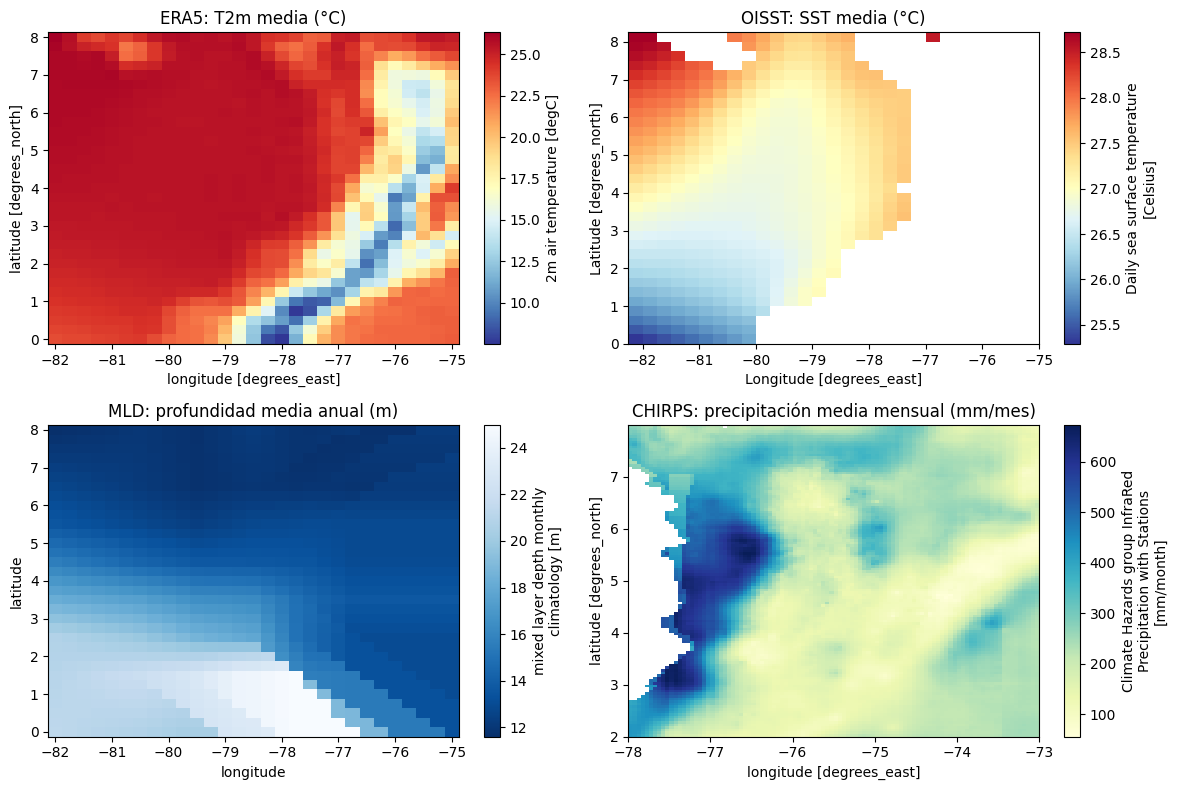

Figura guardada.


In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# ERA5: t2m promedio
era5["t2m"].mean(dim="time").plot(ax=axes[0,0], cmap="RdYlBu_r")
axes[0,0].set_title("ERA5: T2m media (°C)")

# OISST: SST promedio
oisst["sst"].mean(dim="time").plot(ax=axes[0,1], cmap="RdYlBu_r")
axes[0,1].set_title("OISST: SST media (°C)")

# MLD: promedio anual
mld["mld"].mean(dim="month").plot(ax=axes[1,0], cmap="Blues_r")
axes[1,0].set_title("MLD: profundidad media anual (m)")

# CHIRPS: precipitacion media mensual
chirps["precip"].mean(dim="time").plot(ax=axes[1,1], cmap="YlGnBu")
axes[1,1].set_title("CHIRPS: precipitación media mensual (mm/mes)")

plt.tight_layout()
plt.savefig("../docs/fig_control_calidad_datos.png", dpi=150)
plt.show()
print("Figura guardada.")

In [27]:
# En preprocesamiento.ipynb
# Ver valores brutos de strd para el primer dia
lw_raw = xr.open_dataset("../datos/ERA5/era5_surface_thermal_radiation_downwards_1980.nc")
print(lw_raw)
print("\nValores strd primer dia (8 timesteps):")
print(lw_raw["strd"].isel(valid_time=slice(0,8)).values[:,0,0])

<xarray.Dataset> Size: 11MB
Dimensions:     (valid_time: 2928, latitude: 33, longitude: 29)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 23kB 1980-01-01 ... 1980-12-31T21...
    expver      (valid_time) <U4 47kB ...
  * latitude    (latitude) float64 264B 8.0 7.75 7.5 7.25 ... 0.75 0.5 0.25 0.0
  * longitude   (longitude) float64 232B -82.0 -81.75 -81.5 ... -75.25 -75.0
    number      int64 8B ...
Data variables:
    strd        (valid_time, latitude, longitude) float32 11MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-16T19:27 GRIB to CDM+CF via cfgrib-0.9.1...

Valores strd primer dia (8 timesteps):
[1.5315980e+06 1.5198290e+06 1.5206984e+06 1.5067884e+06 1.4871950e+06
 1.4953430e+06 1.5089890e+06 1.5147550

In [28]:
# Verificar: diferencia entre timesteps consecutivos del mismo dia
vals = lw_raw["strd"].isel(valid_time=slice(0,8)).values[:,16,14]
print("Acumulados brutos (J/m2):", vals.round(0))
print("Diferencias entre timesteps (J/m2):", np.diff(vals).round(0))
print()
# Flujo en cada ventana de 3h (W/m2)
flujos_3h = np.diff(vals) / 10800.0
print("Flujo por ventana de 3h (W/m2):", flujos_3h.round(1))
print("Flujo medio diario (W/m2):", flujos_3h.mean().round(1))
print()
# Vs lo que calculamos antes (acumulado/10800)
print("Lo que calculamos antes (W/m2):", (vals / 10800).round(1))

Acumulados brutos (J/m2): [1.537646e+06 1.523317e+06 1.515962e+06 1.523748e+06 1.531035e+06
 1.551407e+06 1.560253e+06 1.531107e+06]
Diferencias entre timesteps (J/m2): [-14329.  -7355.   7786.   7287.  20372.   8846. -29146.]

Flujo por ventana de 3h (W/m2): [-1.3 -0.7  0.7  0.7  1.9  0.8 -2.7]
Flujo medio diario (W/m2): -0.1

Lo que calculamos antes (W/m2): [142.4 141.  140.4 141.1 141.8 143.6 144.5 141.8]


In [29]:
print("Timesteps y valores strd (J/m2) primeros 16:")
for i in range(16):
    t = lw_raw["valid_time"].values[i]
    v = lw_raw["strd"].values[i, 16, 14]
    print(f"  {t}  {v:.0f}")

Timesteps y valores strd (J/m2) primeros 16:
  1980-01-01T00:00:00.000000000  1537646
  1980-01-01T03:00:00.000000000  1523317
  1980-01-01T06:00:00.000000000  1515962
  1980-01-01T09:00:00.000000000  1523748
  1980-01-01T12:00:00.000000000  1531035
  1980-01-01T15:00:00.000000000  1551407
  1980-01-01T18:00:00.000000000  1560253
  1980-01-01T21:00:00.000000000  1531107
  1980-01-02T00:00:00.000000000  1548731
  1980-01-02T03:00:00.000000000  1550397
  1980-01-02T06:00:00.000000000  1543133
  1980-01-02T09:00:00.000000000  1544256
  1980-01-02T12:00:00.000000000  1543386
  1980-01-02T15:00:00.000000000  1557376
  1980-01-02T18:00:00.000000000  1536779
  1980-01-02T21:00:00.000000000  1514962


In [30]:
print(lw_raw["strd"].attrs)

{'GRIB_paramId': np.int64(175), 'GRIB_dataType': 'fc', 'GRIB_numberOfPoints': np.int64(957), 'GRIB_typeOfLevel': 'surface', 'GRIB_stepUnits': np.int64(1), 'GRIB_stepType': 'accum', 'GRIB_gridType': 'regular_ll', 'GRIB_uvRelativeToGrid': np.int64(0), 'GRIB_NV': np.int64(0), 'GRIB_Nx': np.int64(29), 'GRIB_Ny': np.int64(33), 'GRIB_cfName': 'unknown', 'GRIB_cfVarName': 'strd', 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid', 'GRIB_iDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_iScansNegatively': np.int64(0), 'GRIB_jDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_jPointsAreConsecutive': np.int64(0), 'GRIB_jScansPositively': np.int64(0), 'GRIB_latitudeOfFirstGridPointInDegrees': np.float64(8.0), 'GRIB_latitudeOfLastGridPointInDegrees': np.float64(0.0), 'GRIB_longitudeOfFirstGridPointInDegrees': np.float64(-82.0), 'GRIB_longitudeOfLastGridPointInDegrees': np.float64(-75.0), 'GRIB_missingValue': np.float64(3.4028234663852886e+38), 'GRIB_name': 'Surface long-wave (ther

In [32]:
# Verificar el archivo original a las 12:00
lw_orig = xr.open_dataset("../datos/ERA5/era5_surface_thermal_radiation_downwards_1980_2023.nc")
print(lw_orig)
print("\nValores strd a las 12:00 (J/m2) primeros 5 dias:")
print(lw_orig["strd"].values[:5, 16, 14])
print("\nConversion a W/m2 (dividir por 43200 s = 12h):")
print((lw_orig["strd"].values[:5, 16, 14] / 43200).round(1))

<xarray.Dataset> Size: 62MB
Dimensions:     (valid_time: 16071, latitude: 33, longitude: 29)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 129kB 1980-01-01T12:00:00 ... 202...
    expver      (valid_time) <U4 257kB ...
  * latitude    (latitude) float64 264B 8.0 7.75 7.5 7.25 ... 0.75 0.5 0.25 0.0
  * longitude   (longitude) float64 232B -82.0 -81.75 -81.5 ... -75.25 -75.0
    number      int64 8B ...
Data variables:
    strd        (valid_time, latitude, longitude) float32 62MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-16T04:37 GRIB to CDM+CF via cfgrib-0.9.1...

Valores strd a las 12:00 (J/m2) primeros 5 dias:
[1.5310350e+06 1.5433860e+06 1.5404830e+06 1.5286162e+06 1.5111548e+06]

Conversion a W/m2 (divid

In [33]:
# Comparar con valores tipicos de literatura
# LW descendente tropical: ~390-420 W/m2 (Kiehl & Trenberth 1997, Wild et al 2013)
# Nuestros valores: ~35 W/m2 -> factor de ~11 de diferencia

# Revisar si hay un factor de escala en los atributos
lw_12h = xr.open_dataset("../datos/ERA5/era5_surface_thermal_radiation_downwards_1980_2023.nc")
print("scale_factor:", lw_12h["strd"].encoding.get("scale_factor", "no"))
print("add_offset:", lw_12h["strd"].encoding.get("add_offset", "no"))
print("GRIB_stepRange:", lw_12h["strd"].attrs.get("GRIB_stepRange", "no attr"))
print("GRIB_stepType:", lw_12h["strd"].attrs.get("GRIB_stepType", "no attr"))
print("GRIB_dataType:", lw_12h["strd"].attrs.get("GRIB_dataType", "no attr"))
print("\nValor bruto max:", float(lw_12h["strd"].max()))
print("Valor bruto min:", float(lw_12h["strd"].min()))

scale_factor: no
add_offset: no
GRIB_stepRange: no attr
GRIB_stepType: accum
GRIB_dataType: fc

Valor bruto max: 1643192.25
Valor bruto min: 681608.3125


In [34]:
# Si el forecast arranca a las 06:00 UTC del dia anterior
# y el timestep es 12:00 UTC del dia actual
# el acumulado tiene 30 horas = 108000 segundos

for divisor, label in [(43200, "12h"), (86400, "24h"), (108000, "30h"), (3600, "1h")]:
    val = 1531035 / divisor
    print(f"Dividiendo por {label} ({divisor}s): {val:.1f} W/m2")

Dividiendo por 12h (43200s): 35.4 W/m2
Dividiendo por 24h (86400s): 17.7 W/m2
Dividiendo por 30h (108000s): 14.2 W/m2
Dividiendo por 1h (3600s): 425.3 W/m2


In [35]:
sw_12h = xr.open_dataset("../datos/ERA5/era5_surface_solar_radiation_downwards_1980_2023.nc")
print("SW bruto max:", float(sw_12h["ssrd"].max()))
print("SW bruto min:", float(sw_12h["ssrd"].min()))
print()
for divisor, label in [(43200, "12h"), (86400, "24h"), (3600, "1h")]:
    val_max = float(sw_12h["ssrd"].max()) / divisor
    val_mean = float(sw_12h["ssrd"].mean()) / divisor
    print(f"Dividiendo por {label}: max={val_max:.1f}, mean={val_mean:.1f} W/m2")

SW bruto max: 525632.0
SW bruto min: 0.0

Dividiendo por 12h: max=12.2, mean=2.1 W/m2
Dividiendo por 24h: max=6.1, mean=1.1 W/m2
Dividiendo por 1h: max=146.0, mean=25.8 W/m2
